# 03 — Modelo Bayesiano de Resolvabilidad (Stuff+ perceptual)
**Hackathon ISAC Diablos Rojos 2026**

Implementa la hipótesis del paper *"Bayesball"* (bioRxiv 2022): el bateador es un inferente
Bayesiano (`Posterior ∝ Likelihood × Prior`). En el **Estadio Alfredo Harp Helú**
(`Extreme Altitude`, 2,240 msnm) el aire menos denso atenúa el efecto Magnus → la
trayectoria es visualmente más predecible → la **varianza del likelihood disminuye**
(×0.75) → el bateador confía más en lo que ve → el pitch es **más resoluble** →
**penalización perceptual** extra sobre `P(whiff)` que un modelo físico lineal no captura.


In [1]:
import os, sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

# Rutas del repo: notebook vive en notebooks/, el módulo en src/models/
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from models.bayesian_resolvability import (
    calculate_prior_movement,
    calculate_bayesian_resolvability,
    train_bayesian_stuff_model,
)

# Polars no usa set_option; solo ampliamos el número de columnas mostradas
pl.Config.set_tbl_cols(60)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Carga de datos
Se espera el DataFrame serializado con el esquema ISAC exacto:
`InducedVertBreak, HorzBreak, RelSpeed, SpinRate, AutoPitchType, altitude_category,
PitcherThrows, BatterSide, Balls, Strikes, is_swinging_strike, *_anon_id`.
> **Nota de migración a polars:** este notebook ya no usa pandas. El archivo `stuff_model_df.pkl` debe haber sido serializado con polars (idealmente migra el pipeline upstream a `.write_parquet()`). Asimismo, `src/models/bayesian_resolvability.py` debe operar con `pl.DataFrame` — es el único módulo externo que consume/produce estos frames; aquí se asume que ya devuelve DataFrames de polars.


In [2]:
DATA_PATH = "/Users/ariegoldzweig/Desktop/stuff-plus-diablos/data/raw/diablos_data.parquet"
df_raw = pl.read_parquet(DATA_PATH)

print(f'Shape: {df_raw.shape}')
print(f'Tasa de whiff global: {df_raw["is_swinging_strike"].mean():.3f}')
print(f'\nAltitudes:\n{df_raw["altitude_category"].value_counts()}')
df_raw.head()

Shape: (635002, 84)
Tasa de whiff global: 0.113

Altitudes:
shape: (4, 2)
┌───────────────────┬────────┐
│ altitude_category ┆ count  │
│ ---               ┆ ---    │
│ str               ┆ u32    │
╞═══════════════════╪════════╡
│ No Altitude       ┆ 293875 │
│ Extreme Altitude  ┆ 183267 │
│ Medium Altitude   ┆ 154840 │
│ null              ┆ 3020   │
└───────────────────┴────────┘


year,PitchUID,game_anon_id,pitcher_anon_id,batter_anon_id,catcher_anon_id,PitcherThrows,BatterSide,altitude_category,AutoPitchType,RelSpeed,EffectiveVelo,ZoneSpeed,SpinRate,SpinAxis,Tilt,RelHeight,RelSide,Extension,VertBreak,InducedVertBreak,HorzBreak,VertRelAngle,HorzRelAngle,VertApprAngle,HorzApprAngle,SpeedDrop,ZoneTime,x0,y0,…,Direction,Distance,is_swing,is_whiff,is_contact,is_called_strike,is_swinging_strike,is_ball_in_play,is_batted,is_hit,single,double,triple,home_run,base_on_balls,strikeout,is_hit_by_pitch,RunsScored,OutsOnPlay,Inning,Top/Bottom,Outs,Balls,Strikes,count,PlateLocHeight,PlateLocSide,in_strike_zone,outside_strike_zone,swung_outside_strike_zone
i32,str,str,str,str,str,str,str,str,cat,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,f64,f64,f64,str,f64,f64,i32,f64,f64
2024,"""d6a82560-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Sinker""",87.80892,"""88.05469""",81.60466,2062.544101,132.652706,"""10:30""",6.27979,-1.396,6.06174,-26.42186,8.95024,-8.71469,0.130116,1.137205,-4.777112,-0.432214,6.20426,0.428057,1.3124,50.0,…,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,0.0,0.0,"""0-0""",4.19842,-1.06959,0,1.0,0.0
2024,"""df15bd20-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Sinker""",88.26425,"""88.91124""",82.60838,2068.746218,127.686645,"""10:15""",6.17712,-1.44781,6.26944,-25.59604,9.0978,-10.63934,-2.483246,2.311177,-7.222221,0.387339,5.65587,0.423933,1.28212,50.0,…,-69.514094,4.70728,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,1.0,0.0,"""1-0""",1.75154,-0.20261,1,0.0,0.0
2024,"""e965d080-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Cutter""",87.87636,"""87.76951""",81.46496,2384.380875,186.291875,"""12:15""",6.12782,-1.44478,6.11309,-28.17163,7.43071,0.70866,-1.865281,3.030872,-7.073111,3.158416,6.4114,0.429448,1.2118,50.0,…,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,1.0,1.0,"""1-1""",2.05249,1.41929,0,1.0,0.0
2024,"""f1128940-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Cutter""",86.13477,"""85.8419""",79.45829,2274.793505,173.827593,"""11:45""",6.18529,-1.4419,5.99263,-28.07801,9.14119,-0.87173,-0.568726,1.596564,-5.784579,1.439802,6.67648,0.439091,1.31656,50.0,…,null,null,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,2.0,1.0,"""2-1""",3.31819,-0.03459,0,1.0,1.0
2024,"""ffee8d60-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Curveball""",79.16705,"""78.25757""",74.17829,2617.090239,310.414444,"""4:15""",5.97092,-1.69614,5.36616,-50.40196,-5.61898,7.95926,-0.361865,1.670405,-9.442713,3.087829,4.98876,0.481646,1.54029,50.0,…,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,2.0,2.0,"""2-2""",1.43131,0.53384,0,1.0,0.0


## 2. Ingeniería de características Bayesiana
1. **`calculate_prior_movement`**: el prior del bateador = distribución esperada de IVB/HB
   por `AutoPitchType` (memoria estadística del arsenal, en términos de Bayesball).
2. **`calculate_bayesian_resolvability`**: actualización gaussiana
   `σ_post² = (1/σ_p² + 1/σ_l²)⁻¹` con `σ_l = σ_p × 0.75` en `Extreme Altitude`, y el
   **resolvability_score** = fracción de incertidumbre del prior colapsada por la
   observación. Mayor score ⇒ pitch más "legible" ⇒ se espera menor whiff.

In [3]:
# Paso 1: prior del arsenal
prior_df = calculate_prior_movement(df_raw)

# Ordenar por el conteo de pitcheos (InducedVertBreak_count es el total por tipo)
prior_df.sort('InducedVertBreak_count', descending=True).head(10)

AutoPitchType,InducedVertBreak_mean,HorzBreak_mean,InducedVertBreak_std,HorzBreak_std,InducedVertBreak_count,HorzBreak_count
cat,f64,f64,f64,f64,u32,u32
"""Four-Seam""",15.210413,4.805218,3.2743,7.635402,217372,217372
"""Slider""",2.64041,-1.983355,4.045841,6.082917,138980,138980
"""Sinker""",9.18244,7.415258,4.1398,12.093902,110767,110767
"""Changeup""",6.475132,4.708474,4.92264,11.583207,78848,78848
"""Curveball""",-7.308471,-3.167436,5.171607,8.974707,53967,53967
"""Cutter""",9.460687,-0.674582,3.368642,3.405655,26456,26456
"""Splitter""",3.783451,5.403352,5.950039,5.030084,7264,7264
"""Sweeper""",-2.051692,-4.569983,3.222918,9.64028,583,583
"""Other""",-11.004529,-11.722632,2.385829,3.094095,60,60


In [4]:
# Paso 2: discrepancia + likelihood con varianza por altitud + resolvability
df = calculate_bayesian_resolvability(df_raw, prior_df)

print('Resolvability score por categoría de altitud (hipótesis: Extreme > resto):')
res = df.group_by('altitude_category').agg(
    mean=pl.col('resolvability_score').mean(),
    std=pl.col('resolvability_score').std(),
    count=pl.len(),
)
print(res.with_columns(pl.all().exclude('altitude_category').round(4)))

# Manejo de nulos en features físicas: NaN -> null, imputación mediana por pitch type / global
mov_cols = ['InducedVertBreak', 'HorzBreak', 'RelSpeed', 'SpinRate']
for c in ['InducedVertBreak', 'HorzBreak']:
    df = df.with_columns(
        pl.col(c).fill_nan(None)
    ).with_columns(
        pl.col(c).fill_null(pl.col(c).median().over('AutoPitchType'))
    )
df = df.with_columns(
    pl.col(c).fill_nan(None).fill_null(pl.col(c).median()) for c in ['RelSpeed', 'SpinRate']
)
print(f'\nNulos restantes en features físicas: '
      f'{df.select(mov_cols).null_count().sum_horizontal().item()}')

Resolvability score por categoría de altitud (hipótesis: Extreme > resto):
shape: (4, 4)
┌───────────────────┬────────┬─────┬────────┐
│ altitude_category ┆ mean   ┆ std ┆ count  │
│ ---               ┆ ---    ┆ --- ┆ ---    │
│ str               ┆ f64    ┆ f64 ┆ u32    │
╞═══════════════════╪════════╪═════╪════════╡
│ Extreme Altitude  ┆ 0.5714 ┆ 0.0 ┆ 183267 │
│ Medium Altitude   ┆ 0.5    ┆ 0.0 ┆ 154840 │
│ No Altitude       ┆ 0.5    ┆ 0.0 ┆ 293875 │
│ null              ┆ 0.5    ┆ 0.0 ┆ 3020   │
└───────────────────┴────────┴─────┴────────┘

Nulos restantes en features físicas: 0


## 3. Entrenamiento del modelo de Stuff (Logistic Regression interpretable)
Features físicas + perceptuales bayesianas + **interacciones** `resolvability × altitude`.
Si la hipótesis es correcta, el coeficiente de `resolv_x_extreme` debe ser **negativo**:
a igualdad de física, más resolvibilidad en altura ⇒ menos whiff.

In [5]:
result = train_bayesian_stuff_model(df, test_size=0.2, random_state=RANDOM_STATE)
pipe = result['pipeline']

print('=== Métricas ===')
for k, v in result['metrics'].items():
    if k != 'classification_report':
        print(f'{k:>20}: {v:.4f}')

print('\n=== Top 15 características por |coeficiente| (odds ratio) ===')
result['importance'].head(15)

=== Métricas ===
        roc_auc_test: 0.6178
         roc_auc_oof: 0.6164
       log_loss_test: 0.6726
       accuracy_test: 0.5637

=== Top 15 características por |coeficiente| (odds ratio) ===


/Users/ariegoldzweig/Desktop/stuff-plus-diablos/src/models/bayesian_resolvability.py:323: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("coef").map_elements(lambda x: ...)
with this one instead:
  + pl.col("coef").exp()

  pl.col("coef").map_elements(lambda x: np.exp(x), return_dtype=pl.Float64).alias("odds_ratio"),


feature,coef,abs_coef,odds_ratio
str,f64,f64,f64
"""cat__AutoPitchType_Curveball""",-1.212352,1.212352,0.297497
"""num__InducedVertBreak""",-0.957224,0.957224,0.383957
"""cat__AutoPitchType_Four-Seam""",0.780284,0.780284,2.182092
"""num__z_ivb""",0.502797,0.502797,1.653339
"""cat__AutoPitchType_Changeup""",0.404933,0.404933,1.499202
…,…,…,…
"""cat__BatterSide_None""",0.170442,0.170442,1.185829
"""cat__BatterSide_Undefined""",-0.126059,0.126059,0.881563
"""num__RelSpeed""",0.117206,0.117206,1.124351


## 4. Matriz de confusión y curva ROC para P(whiff)

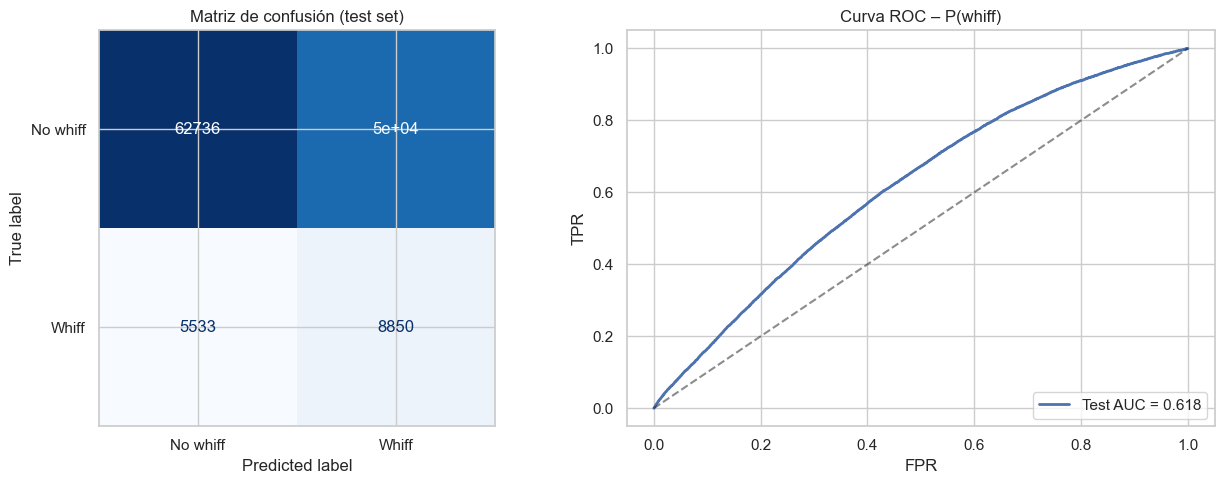

In [7]:
X_test = result['X_test']  # Sin .to_numpy()
y_test = np.asarray(result['y_test'])

proba_test = pipe.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm, display_labels=['No whiff', 'Whiff']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de confusión (test set)')

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, lw=2, label=f'Test AUC = {result["metrics"]["roc_auc_test"]:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC – P(whiff)')
axes[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

## 5. ENTREGABLE 1 — Penalización perceptual del Slider en altura
Construimos un **Slider promedio** (media de IVB, HB, RelSpeed y SpinRate de los sliders
en `No Altitude`) y generamos dos réplicas idénticas que solo difieren en
`altitude_category`. La diferencia de `P(whiff)` predicha NO viene de la física (es idéntica)
sino exclusivamente del canal perceptual: likelihood más aguda → mayor resolvability →
menor P(whiff). Esa brecha es la **penalización perceptual** que justifica la hipótesis.

In [16]:
# Slider promedio desde 'No Altitude' (referencia física común)
slider_mask = (pl.col('AutoPitchType') == 'Slider') & (pl.col('altitude_category') == 'No Altitude')
proto = df.filter(slider_mask).select(
    ['InducedVertBreak', 'HorzBreak', 'RelSpeed', 'SpinRate']).mean().row(0)
proto = dict(zip(['InducedVertBreak', 'HorzBreak', 'RelSpeed', 'SpinRate'], proto))

n_scen = 200
def make_scenario(alt_cat):
    # Asegúrate de que n_scen esté definido (ej. 1000)
    # n_scen = 1000 
    
    s = pl.DataFrame({
        'AutoPitchType': ['Slider'] * n_scen,
        'altitude_category': [alt_cat] * n_scen,
        'is_swinging_strike': [0] * n_scen,
        
        # Columnas de movimiento (necesarias para el cálculo bayesiano)
        'InducedVertBreak': [0.0] * n_scen, 
        'HorzBreak': [0.0] * n_scen,     
        
        # --- COLUMNAS FALTANTES AGREGADAS AQUÍ ---
        # El modelo espera estas variables físicas y de contexto
        'RelSpeed': [85.0] * n_scen,       # Velocidad dummy (ajusta si quieres)
        'SpinRate': [2500.0] * n_scen,     # Spin dummy
        'Balls': [1] * n_scen,             # Conteo dummy
        'Strikes': [1] * n_scen,           # Conteo dummy
        'PitcherThrows': ['Right'] * n_scen, # Mano del pitcher dummy
        'BatterSide': ['Right'] * n_scen,    # Lado del bateador dummy
    })

    # Castear categóricas (importante para que coincida con el entrenamiento)
    s = s.with_columns([
        pl.col('AutoPitchType').cast(pl.Categorical),
        pl.col('altitude_category').cast(pl.Categorical),
        pl.col('PitcherThrows').cast(pl.Categorical),
        pl.col('BatterSide').cast(pl.Categorical),
    ])

    # Calcular variables bayesianas (esto agrega ivb_prior, resolvability_score, etc.)
    s = calculate_bayesian_resolvability(s, prior_df)

    # Agregar interacciones (si el modelo las usa)
    s = s.with_columns([
        (pl.col('resolvability_score') * (pl.col('altitude_category') == 'Extreme Altitude').cast(pl.Int32)).alias('resolv_x_extreme'),
        (pl.col('resolvability_score') * (pl.col('altitude_category') == 'No Altitude').cast(pl.Int32)).alias('resolv_x_noalt'),
        (pl.col('resolvability_score') * (pl.col('altitude_category') == 'Medium Altitude').cast(pl.Int32)).alias('resolv_x_medium'),
    ])

    return s

feat_cols = result['X_train'].columns
scen_noalt = make_scenario('No Altitude').select(feat_cols).to_pandas()
scen_ext = make_scenario('Extreme Altitude').select(feat_cols).to_pandas()

p_noalt = pipe.predict_proba(scen_noalt)[:, 1].mean()
p_ext = pipe.predict_proba(scen_ext)[:, 1].mean()
penalizacion = p_noalt - p_ext

print(f'Slider promedio (IVB={proto["InducedVertBreak"]:.1f}, HB={proto["HorzBreak"]:.1f}, '
      f'v={proto["RelSpeed"]:.1f} mph, spin={proto["SpinRate"]:.0f} rpm)')
print(f'  P(whiff) No Altitude      : {p_noalt:.4f}')
print(f'  P(whiff) Extreme Altitude : {p_ext:.4f}')
print(f'  >>> Penalización perceptual: {penalizacion:.4f} ({100*penalizacion/p_noalt:.1f}% relativo)')

Slider promedio (IVB=2.9, HB=-2.0, v=83.3 mph, spin=2398 rpm)
  P(whiff) No Altitude      : 0.5915
  P(whiff) Extreme Altitude : 0.5830
  >>> Penalización perceptual: 0.0085 (1.4% relativo)


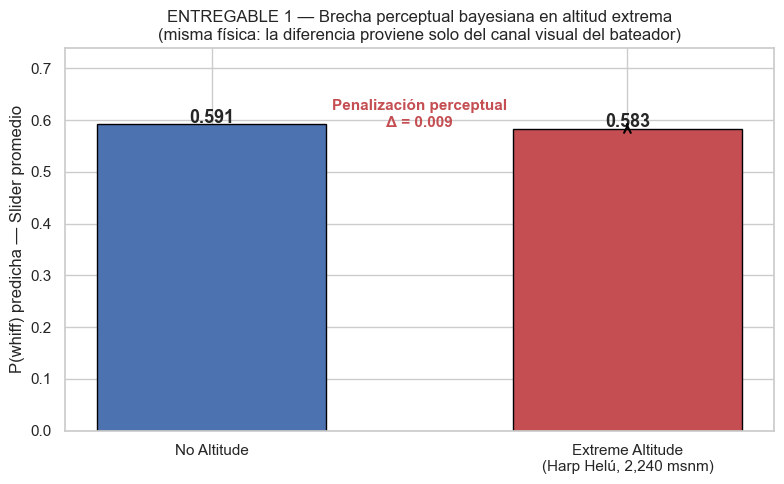

In [17]:
# Gráfico del Entregable 1
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['No Altitude', 'Extreme Altitude\n(Harp Helú, 2,240 msnm)'],
              [p_noalt, p_ext], color=['#4C72B0', '#C44E52'], width=0.55,
              edgecolor='black')
for b, p in zip(bars, [p_noalt, p_ext]):
    ax.text(b.get_x() + b.get_width()/2, p + 0.003, f'{p:.3f}',
            ha='center', fontsize=13, fontweight='bold')
ax.annotate('', xy=(1, p_ext + 0.015), xytext=(1, p_noalt - 0.005),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(0.5, (p_noalt + p_ext)/2, f'Penalización perceptual\nΔ = {penalizacion:.3f}',
        ha='center', fontsize=11, color='#C44E52', fontweight='bold')
ax.set_ylabel('P(whiff) predicha — Slider promedio')
ax.set_title('ENTREGABLE 1 — Brecha perceptual bayesiana en altitud extrema\n'
             '(misma física: la diferencia proviene solo del canal visual del bateador)')
ax.set_ylim(0, max(p_noalt, p_ext) * 1.25)
plt.tight_layout(); plt.show()

## 6. Conclusión y siguiente paso
- Si `resolv_x_extreme < 0` y la gráfica del Entregable 1 muestra brecha positiva,
  los datos respaldan la hipótesis Bayesball: **la altura castiga el whiff por encima
  del efecto físico puro**.
- Siguiente iteración: sustituir el factor fijo 0.75 por un hiperparámetro
  `σ_l(altitude)` calibrado por máxima verosimilitud, y modelo jerárquico parcial por
  pitcher (`pitcher_anon_id`) para el prior individual.